In [3]:
import pandas as pd

df = pd.read_excel('Real school data.xlsx')
# if it's in Google Drive: mount drive first, then use the full path,
# e.g. '/content/drive/MyDrive/.../EarlyFlag_cleaned_FINAL_v2.xlsx'

print("Shape:", df.shape)
print("\n--- Missingness ---")
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))

print("\n--- Cardinality of object/string columns ---")
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()[:15]}")

print("\n--- Suspicious constant columns ---")
for col in df.columns:
    if df[col].nunique() <= 1:
        print(f"{col}: constant value = {df[col].unique()}")

print("\n--- Redundancy check ---")
if 'Household income level' in df.columns and 'Household income level (standardized)' in df.columns:
    print(pd.crosstab(df['Household income level'], df['Household income level (standardized)']))

if 'level_prefix' in df.columns:
    print("level_prefix non-null count:", df['level_prefix'].notna().sum(), "/", len(df))
if 'subgroup' in df.columns:
    print("subgroup non-null count:", df['subgroup'].notna().sum(), "/", len(df))

if 'long_commute_flag' in df.columns:
    print(df.groupby('long_commute_flag')['Travel time to school (minutes)'].describe())
if 'long_walk_flag' in df.columns:
    print(pd.crosstab(df['long_walk_flag'], df['Mode of transport']))

print("\n--- Continuous ranges (sanity check for scale bugs) ---")
num_cols = ['Semester 1 average', 'Semester 2 average', 'Semester difference',
            'Travel time to school (minutes)', 'grade_number']
for col in num_cols:
    if col in df.columns:
        print(f"{col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}")

print("\n--- Section / stream_letter distribution (edge-construction signal) ---")
if 'Section' in df.columns:
    print(df['Section'].value_counts())
if 'stream_letter' in df.columns:
    print(df['stream_letter'].value_counts(dropna=False))

Shape: (1000, 34)

--- Missingness ---
Household income level (standardized)    63
Parental educational level               59
Extra-curricular activities              15
Class level                               5
dtype: int64

--- Cardinality of object/string columns ---
School: 4 unique -> ['Shining Star' 'Shining Star Preparatory' 'Weweso MA' 'Ayeduase RC']
Name: 290 unique -> ['Theophilus Yaw Akyen' 'Asiama Isaac Ebenezer' 'Edudzi Sabaina'
 'Nana Afia Antwiwaa' 'Samuel Adenyina' 'Monalisa Owusuaa Boateng'
 'Boye Fanicia' 'Benita Abraham' 'Mercedes Gyamfuaa Boakye'
 'Rebecca Afumwoah' 'Nana Akea Abishaq' 'Mensah Felicia' 'Akwasi Combert'
 'Janice Naganeah' 'Maxwell Nana Obiri Yeboah Antwi']
Gender: 2 unique -> ['Female' 'Male']
Class level: 21 unique -> ['4A' '4B' '7B3' '5' '6B' '5A' '5B' '5B2' '4' 'JHS 1' '6A' 'JHS 1B1' '7B2'
 '6B2' '6']
Parental educational level: 5 unique -> ['SHS' 'Tertiary' 'JHS' 'Basic' 'University' nan]
Household income level: 11 unique -> ['3' 'yes' '2' '1'

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_excel('Real school data.xlsx')

# --- fix grade_number contamination ---
df['grade_number'] = df['grade_number'].round().astype(int)

# --- binary ---
df['Gender_enc'] = (df['Gender'] == 'Female').astype(int)

# --- ordinal (order matters, preserve it) ---
edu_order = {'JHS': 0, 'SHS': 1, 'Tertiary': 2}
df['Parental_edu_enc'] = df['Parental educational level'].map(edu_order)

child_labor_order = {'No': 0, 'Sometimes': 1, 'Yes': 2}
df['Child_labor_enc'] = df['Child labor involvement'].map(child_labor_order)

rel_order = {'Poor': 0, 'Average': 1, 'Good': 2}
df['Teacher_rel_enc'] = df['Teacher relationship quality'].map(rel_order)
df['Peer_rel_enc'] = df['Peer relationship quality'].map(rel_order)
# Household income level (int, 1/2/3) already ordinal — use as-is, drop the standardized string twin

# --- nominal, one-hot (no natural order) ---
onehot_cols = ['School', 'Family dropout history', 'Mode of transport',
               'Extra-curricular activities']
df = pd.get_dummies(df, columns=onehot_cols, prefix=onehot_cols, dtype=int)

# --- structural-NaN categoricals: explicit "none" category before one-hot ---
df['subgroup_cat'] = df['subgroup'].fillna(-1).astype(int).astype(str)
df['stream_letter_cat'] = df['stream_letter'].fillna('none')
df = pd.get_dummies(df, columns=['subgroup_cat', 'stream_letter_cat'],
                     prefix=['subgroup', 'stream'], dtype=int)

# --- continuous: scale ---
cont_cols = ['Semester 1 average', 'Semester 2 average', 'Semester difference',
             'Travel time to school (minutes)']
scaler = StandardScaler()
df[cont_cols] = scaler.fit_transform(df[cont_cols])
# Week1-14_attendance already 0-1, no rescaling

# --- drop redundant / non-feature columns ---
df = df.drop(columns=[
    'Student ID', 'Class level', 'Travel time to school',
    'Household income level (standardized)', 'level_prefix',
    'Gender', 'Parental educational level', 'Child labor involvement',
    'Teacher relationship quality', 'Peer relationship quality',
    'subgroup', 'stream_letter'
])

# Section and Class-level components kept OUT of node features on purpose —
# reserve for edge construction, per the plan's peer-graph fix
print(df.shape)
print(df.columns.tolist())

KeyError: 'grade_number'

In [ ]:
df_raw = pd.read_excel('EarlyFlag_cleaned_FINAL_v2.xlsx')
print(pd.crosstab(df_raw['School'], df_raw['Section']))

Section                   James Aggrey  K.A. Busia  Kofi Annan  Kwame Nkrumah  \
School                                                                          
Ayeduase RC                          5          39         634             40   
Shining Star Preparatory            25         106        1624            126   
Weweso MA                           12          63        1039             96   

Section                   Kwegyir Aggrey  
School                                    
Ayeduase RC                           24  
Shining Star Preparatory              80  
Weweso MA                             87  


In [ ]:
import numpy as np

week_cols = [f'Week{i}_attendance' for i in range(1, 15)]
weeks = np.arange(1, 15)

# vectorized linear regression slope per row (attendance trend over the semester)
attendance_matrix = df[week_cols].to_numpy(dtype=float)
weeks_centered = weeks - weeks.mean()
denom = (weeks_centered ** 2).sum()

df['attendance_trend'] = (attendance_matrix * weeks_centered).sum(axis=1) / denom

# optional but recommended: overall level, since trend alone can't distinguish
# "always low" from "always high" — both slope near 0
df['attendance_mean'] = attendance_matrix.mean(axis=1)

df = df.drop(columns=week_cols)

print(df[['attendance_trend', 'attendance_mean']].describe())

       attendance_trend  attendance_mean
count       4000.000000      4000.000000
mean           0.000341         0.879271
std            0.019519         0.074748
min           -0.067253         0.539286
25%           -0.012747         0.832143
50%            0.000000         0.885714
75%            0.013434         0.928571
max            0.067253         1.000000


In [ ]:
print((df['attendance_trend'] == 0).sum(), '/', len(df))

194 / 4000


In [ ]:
print(df['attendance_mean'].describe(percentiles=[.01, .05, .1]))

count    4000.000000
mean        0.879271
std         0.074748
min         0.539286
1%          0.671429
5%          0.739286
10%         0.778571
50%         0.885714
max         1.000000
Name: attendance_mean, dtype: float64


In [ ]:
print((df['attendance_trend'] == 0).sum(), '/', len(df))

194 / 4000


In [ ]:
df_raw = pd.read_excel('EarlyFlag_cleaned_FINAL_v2.xlsx')
print(pd.crosstab(df_raw['School'], df_raw['Section']))

Section                   James Aggrey  K.A. Busia  Kofi Annan  Kwame Nkrumah  \
School                                                                          
Ayeduase RC                          5          39         634             40   
Shining Star Preparatory            25         106        1624            126   
Weweso MA                           12          63        1039             96   

Section                   Kwegyir Aggrey  
School                                    
Ayeduase RC                           24  
Shining Star Preparatory              80  
Weweso MA                             87  


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

# classroom grouping key — the real peer unit (grade + stream + subgroup)
df['class_group'] = (
    df['grade_number'].astype(str) + '_' +
    df['stream_A'].astype(str) + df['stream_B'].astype(str) + '_' +
    df['subgroup_-1'].astype(str) + df['subgroup_1'].astype(str) +
    df['subgroup_2'].astype(str) + df['subgroup_3'].astype(str)
)

# academic features held OUT of similarity per your call — everything else
# (demographic, socioeconomic, behavioral) is fair game
academic_cols = ['attendance_mean', 'attendance_trend',
                  'Semester 1 average', 'Semester 2 average', 'Semester difference']
non_feature_cols = ['class_group', 'Section']

similarity_cols = [c for c in df.columns
                    if c not in academic_cols + non_feature_cols]

similarity_threshold = 0.85  # starting point, tune after seeing edge density

edges = []

for group_key, group_df in df.groupby('class_group'):
    if len(group_df) < 2:
        continue

    idx = group_df.index.to_numpy()
    feats = group_df[similarity_cols].to_numpy(dtype=float)
    sections = group_df['Section'].to_numpy()

    sim_matrix = cosine_similarity(feats)

    for i, j in combinations(range(len(idx)), 2):
        sim = sim_matrix[i, j]

        # Section as a soft tie-breaker: small boost if they share a section,
        # rather than gating on it — reflects that it's a weak, skewed signal
        if sections[i] == sections[j]:
            sim = min(sim + 0.03, 1.0)

        if sim >= similarity_threshold:
            edges.append((idx[i], idx[j], sim))

edge_df = pd.DataFrame(edges, columns=['source', 'target', 'weight'])

print(f"Total edges: {len(edge_df)}")
print(f"Students with at least one edge: {edge_df[['source','target']].stack().nunique()} / {len(df)}")
print(f"Avg degree: {2 * len(edge_df) / len(df):.2f}")
print(f"Isolated students: {len(df) - edge_df[['source','target']].stack().nunique()}")

Total edges: 320117
Students with at least one edge: 3983 / 4000
Avg degree: 160.06
Isolated students: 17


In [ ]:
import numpy as np

# collect all pairwise similarities (not just above threshold) from one pass,
# so we can see the real distribution instead of guessing at cutoffs
all_sims = []
for group_key, group_df in df.groupby('class_group'):
    if len(group_df) < 2:
        continue
    feats = group_df[similarity_cols].to_numpy(dtype=float)
    sim_matrix = cosine_similarity(feats)
    iu = np.triu_indices(len(feats), k=1)
    all_sims.extend(sim_matrix[iu])

all_sims = np.array(all_sims)
print(pd.Series(all_sims).describe(percentiles=[.5, .75, .9, .95, .99]))

count    542152.000000
mean          0.825387
std           0.101254
min           0.082302
50%           0.852266
75%           0.898787
90%           0.926834
95%           0.940083
99%           0.960483
max           1.000000
dtype: float64


In [ ]:
edges = []
target_percentile = 90  # keep only the top 10% most similar pairs within each group — tune this

for group_key, group_df in df.groupby('class_group'):
    if len(group_df) < 2:
        continue

    idx = group_df.index.to_numpy()
    feats = group_df[similarity_cols].to_numpy(dtype=float)
    sections = group_df['Section'].to_numpy()
    sim_matrix = cosine_similarity(feats)

    iu = np.triu_indices(len(feats), k=1)
    pair_sims = sim_matrix[iu]
    if len(pair_sims) == 0:
        continue
    cutoff = np.percentile(pair_sims, target_percentile)

    for i, j in combinations(range(len(idx)), 2):
        sim = sim_matrix[i, j]
        if sections[i] == sections[j]:
            sim = min(sim + 0.03, 1.0)
        if sim >= cutoff:
            edges.append((idx[i], idx[j], sim))

edge_df = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
print(f"Total edges: {len(edge_df)}")
print(f"Students with at least one edge: {edge_df[['source','target']].stack().nunique()} / {len(df)}")
print(f"Avg degree: {2 * len(edge_df) / len(df):.2f}")
print(f"Isolated students: {len(df) - edge_df[['source','target']].stack().nunique()}")

Total edges: 125178
Students with at least one edge: 3960 / 4000
Avg degree: 62.59
Isolated students: 40


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

# ============================================================
# LOAD
# ============================================================
df = pd.read_excel('EarlyFlag_cleaned_FINAL_v2.xlsx')
df_raw = df.copy()  # keep an unencoded copy for any future crosstabs/checks

# ============================================================
# FIX grade_number contamination from CTGAN sampling
# ============================================================
df['grade_number'] = df['grade_number'].round().astype(int)

# ============================================================
# ENCODE — binary
# ============================================================
df['Gender_enc'] = (df['Gender'] == 'Female').astype(int)

# ============================================================
# ENCODE — ordinal (order preserved)
# ============================================================
edu_order = {'JHS': 0, 'SHS': 1, 'Tertiary': 2}
df['Parental_edu_enc'] = df['Parental educational level'].map(edu_order)

child_labor_order = {'No': 0, 'Sometimes': 1, 'Yes': 2}
df['Child_labor_enc'] = df['Child labor involvement'].map(child_labor_order)

rel_order = {'Poor': 0, 'Average': 1, 'Good': 2}
df['Teacher_rel_enc'] = df['Teacher relationship quality'].map(rel_order)
df['Peer_rel_enc'] = df['Peer relationship quality'].map(rel_order)
# Household income level (int, 1/2/3) already ordinal — kept as-is

# ============================================================
# ENCODE — nominal one-hot
# ============================================================
onehot_cols = ['School', 'Family dropout history', 'Mode of transport',
               'Extra-curricular activities']
df = pd.get_dummies(df, columns=onehot_cols, prefix=onehot_cols, dtype=int)

df['subgroup_cat'] = df['subgroup'].fillna(-1).astype(int).astype(str)
df['stream_letter_cat'] = df['stream_letter'].fillna('none')
df = pd.get_dummies(df, columns=['subgroup_cat', 'stream_letter_cat'],
                     prefix=['subgroup', 'stream'], dtype=int)

# ============================================================
# COLLAPSE attendance — level + trend
# ============================================================
week_cols = [f'Week{i}_attendance' for i in range(1, 15)]
weeks = np.arange(1, 15)
attendance_matrix = df[week_cols].to_numpy(dtype=float)
weeks_centered = weeks - weeks.mean()
denom = (weeks_centered ** 2).sum()

df['attendance_trend'] = (attendance_matrix * weeks_centered).sum(axis=1) / denom
df['attendance_mean'] = attendance_matrix.mean(axis=1)
df = df.drop(columns=week_cols)

# ============================================================
# SCALE continuous
# ============================================================
cont_cols = ['Semester 1 average', 'Semester 2 average', 'Semester difference',
             'Travel time to school (minutes)']
scaler = StandardScaler()
df[cont_cols] = scaler.fit_transform(df[cont_cols])
# attendance_mean/trend and Week columns already handled above

# ============================================================
# DROP non-feature / redundant columns
# ============================================================
df = df.drop(columns=[
    'Student ID', 'Class level', 'Travel time to school',
    'Household income level (standardized)', 'level_prefix',
    'Gender', 'Parental educational level', 'Child labor involvement',
    'Teacher relationship quality', 'Peer relationship quality',
    'subgroup', 'stream_letter'
])

print("Node feature matrix shape:", df.shape)

# ============================================================
# EDGE CONSTRUCTION
# ============================================================
# classroom grouping key — the real peer unit
df['class_group'] = (
    df['grade_number'].astype(str) + '_' +
    df['stream_A'].astype(str) + df['stream_B'].astype(str) + '_' +
    df['subgroup_-1'].astype(str) + df['subgroup_1'].astype(str) +
    df['subgroup_2'].astype(str) + df['subgroup_3'].astype(str)
)

# academic features held out of similarity — node-only, not used to define edges
academic_cols = ['attendance_mean', 'attendance_trend',
                  'Semester 1 average', 'Semester 2 average', 'Semester difference']
non_feature_cols = ['class_group', 'Section']
similarity_cols = [c for c in df.columns if c not in academic_cols + non_feature_cols]

target_percentile = 99.5  # top 3% most similar pairs within each classroom group
section_boost = 0.03    # Section as a soft tie-breaker only, given its skew

edges = []
for group_key, group_df in df.groupby('class_group'):
    if len(group_df) < 2:
        continue

    idx = group_df.index.to_numpy()
    feats = group_df[similarity_cols].to_numpy(dtype=float)
    sections = group_df['Section'].to_numpy()
    sim_matrix = cosine_similarity(feats)

    iu = np.triu_indices(len(feats), k=1)
    pair_sims = sim_matrix[iu]
    if len(pair_sims) == 0:
        continue
    cutoff = np.percentile(pair_sims, target_percentile)

    for i, j in combinations(range(len(idx)), 2):
        sim = sim_matrix[i, j]
        if sections[i] == sections[j]:
            sim = min(sim + section_boost, 1.0)
        if sim >= cutoff:
            edges.append((idx[i], idx[j], sim))

edge_df = pd.DataFrame(edges, columns=['source', 'target', 'weight'])

print(f"Total edges: {len(edge_df)}")
print(f"Students with at least one edge: {edge_df[['source','target']].stack().nunique()} / {len(df)}")
print(f"Avg degree: {2 * len(edge_df) / len(df):.2f}")
print(f"Isolated students: {len(df) - edge_df[['source','target']].stack().nunique()}")

Node feature matrix shape: (4000, 37)
Total edges: 20932
Students with at least one edge: 3476 / 4000
Avg degree: 10.47
Isolated students: 524


In [ ]:
import numpy as np

# ============================================================
# LABEL GENERATION — percentile-anchored proxy
# (attendance-heavier composite, top 28% = High per GES 2022,
#  bottom 27% = Low, remaining ~45% = Medium)
# ============================================================

# z-score each raw signal so attendance and academic features are
# on comparable scales before combining (attendance_mean/trend aren't
# scaled yet; Semester averages/difference already are, but re-zscoring
# here keeps this step self-contained and independent of upstream scaling)
def zscore(s):
    return (s - s.mean()) / s.std()

attendance_signal = (zscore(df['attendance_mean']) + zscore(df['attendance_trend'])) / 2
academic_signal = (zscore(df['Semester 2 average']) + zscore(df['Semester difference'])) / 2

# attendance-heavier weighting: 0.65 / 0.35
# negated because higher attendance/academic standing = LOWER risk
df['risk_score'] = -(0.65 * attendance_signal + 0.35 * academic_signal)

# percentile-anchor: top 28% = High (matches GES 2022 ~28% national JHS
# dropout rate), bottom 27% = Low, remaining ~45% = Medium (skewed toward
# Medium per your call)
risk_pct = df['risk_score'].rank(pct=True)
df['dropout_risk'] = np.select(
    [risk_pct >= 0.72, risk_pct <= 0.27],
    ['High', 'Low'],
    default='Medium'
)

print(df['dropout_risk'].value_counts())
print(df['dropout_risk'].value_counts(normalize=True).round(3))

dropout_risk
Medium    1799
High      1121
Low       1080
Name: count, dtype: int64
dropout_risk
Medium    0.45
High      0.28
Low       0.27
Name: proportion, dtype: float64


In [ ]:
print(df.shape)

(4000, 40)


In [ ]:
self_loops = pd.DataFrame({
    'source': df.index,
    'target': df.index,
    'weight': 1.0
})

edge_df_with_loops = pd.concat([edge_df, self_loops], ignore_index=True)

print(f"Edges before self-loops: {len(edge_df)}")
print(f"Edges after self-loops: {len(edge_df_with_loops)}")

Edges before self-loops: 20932
Edges after self-loops: 24932


In [ ]:
import torch

# columns that are NOT node features — structural/target/intermediate
non_feature_cols = ['class_group', 'Section', 'risk_score', 'dropout_risk']

feature_cols_final = [c for c in df.columns if c not in non_feature_cols]

# sanity check: everything left should be numeric
print(df[feature_cols_final].dtypes.value_counts())

x = torch.tensor(df[feature_cols_final].to_numpy(dtype=float), dtype=torch.float)

# label encoding: Low=0, Medium=1, High=2 (ordinal, matches risk direction)
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = torch.tensor(df['dropout_risk'].map(label_map).to_numpy(), dtype=torch.long)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("y distribution:", torch.bincount(y))

int64      30
float64     6
Name: count, dtype: int64
x shape: torch.Size([4000, 36])
y shape: torch.Size([4000])
y distribution: tensor([1080, 1799, 1121])


In [ ]:
# edge_df_with_loops has 'source', 'target' as one direction per pair (plus self-loops)
# make it bidirectional: add the reverse of every non-self-loop edge
reverse_edges = edge_df_with_loops[edge_df_with_loops['source'] != edge_df_with_loops['target']].copy()
reverse_edges = reverse_edges.rename(columns={'source': 'target', 'target': 'source'})[['source', 'target', 'weight']]

edge_df_bidirectional = pd.concat([edge_df_with_loops, reverse_edges], ignore_index=True)

edge_index = torch.tensor(
    edge_df_bidirectional[['source', 'target']].to_numpy().T,
    dtype=torch.long
)
edge_weight = torch.tensor(
    edge_df_bidirectional['weight'].to_numpy(),
    dtype=torch.float
)

print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)
print("Total directed edges (incl. self-loops):", edge_index.shape[1])

edge_index shape: torch.Size([2, 45864])
edge_weight shape: torch.Size([45864])
Total directed edges (incl. self-loops): 45864


In [ ]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00


In [ ]:
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
import numpy as np

# stratified 70/15/15 split — first split off 70% train, then split
# the remaining 30% evenly into val/test (15/15 of the original total)
indices = np.arange(len(y))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=y.numpy(), random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y.numpy()[temp_idx], random_state=42
)

train_mask = torch.zeros(len(y), dtype=torch.bool)
val_mask = torch.zeros(len(y), dtype=torch.bool)
test_mask = torch.zeros(len(y), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

print(data)
print("Train:", train_mask.sum().item(), "Val:", val_mask.sum().item(), "Test:", test_mask.sum().item())

for name, mask in [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]:
    print(name, "class distribution:", torch.bincount(y[mask]))

Data(x=[4000, 36], edge_index=[2, 45864], edge_attr=[45864], y=[4000], train_mask=[4000], val_mask=[4000], test_mask=[4000])
Train: 2800 Val: 600 Test: 600
Train class distribution: tensor([ 756, 1259,  785])
Val class distribution: tensor([162, 270, 168])
Test class distribution: tensor([162, 270, 168])


In [ ]:
import torch

torch.save(data, 'earlyflag_graph_data.pt')

In [ ]:
from google.colab import files
files.download('earlyflag_graph_data.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv('earlyflag_node_features_df.csv', index=False)
edge_df_bidirectional.to_csv('earlyflag_edges_df.csv', index=False)

In [ ]:
from google.colab import files
files.download('earlyflag_node_features_df.csv')
files.download('earlyflag_edges_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# OLD (bug): grouped across schools
# df['class_group'] = (
#     df['grade_number'].astype(str) + '_' +
#     df['stream_A'].astype(str) + df['stream_B'].astype(str) + '_' +
#     df['subgroup_-1'].astype(str) + df['subgroup_1'].astype(str) +
#     df['subgroup_2'].astype(str) + df['subgroup_3'].astype(str)
# )

# FIXED: school included, so peer groups stay within the same physical school
school_key = (
    df['School_Ayeduase RC'].astype(str) + '_' +
    df['School_Shining Star Preparatory'].astype(str) + '_' +
    df['School_Weweso MA'].astype(str)
)

df['class_group'] = (
    school_key + '_' +
    df['grade_number'].astype(str) + '_' +
    df['stream_A'].astype(str) + df['stream_B'].astype(str) + '_' +
    df['subgroup_-1'].astype(str) + df['subgroup_1'].astype(str) +
    df['subgroup_2'].astype(str) + df['subgroup_3'].astype(str)
)

print("Number of unique classroom groups:", df['class_group'].nunique())
print(df.groupby('class_group').size().describe())

Number of unique classroom groups: 66
count     66.000000
mean      60.606061
std       52.116992
min        1.000000
25%       20.000000
50%       46.500000
75%       80.500000
max      223.000000
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

# ============================================================
# LOAD
# ============================================================
df = pd.read_excel('EarlyFlag_cleaned_FINAL_v2.xlsx')
df_raw = df.copy()  # keep an unencoded copy for any future crosstabs/checks

# ============================================================
# FIX grade_number contamination from CTGAN sampling
# ============================================================
df['grade_number'] = df['grade_number'].round().astype(int)

# ============================================================
# ENCODE — binary
# ============================================================
df['Gender_enc'] = (df['Gender'] == 'Female').astype(int)

# ============================================================
# ENCODE — ordinal (order preserved)
# ============================================================
edu_order = {'JHS': 0, 'SHS': 1, 'Tertiary': 2}
df['Parental_edu_enc'] = df['Parental educational level'].map(edu_order)

child_labor_order = {'No': 0, 'Sometimes': 1, 'Yes': 2}
df['Child_labor_enc'] = df['Child labor involvement'].map(child_labor_order)

rel_order = {'Poor': 0, 'Average': 1, 'Good': 2}
df['Teacher_rel_enc'] = df['Teacher relationship quality'].map(rel_order)
df['Peer_rel_enc'] = df['Peer relationship quality'].map(rel_order)
# Household income level (int, 1/2/3) already ordinal — kept as-is

# ============================================================
# ENCODE — nominal one-hot
# ============================================================
onehot_cols = ['School', 'Family dropout history', 'Mode of transport',
               'Extra-curricular activities']
df = pd.get_dummies(df, columns=onehot_cols, prefix=onehot_cols, dtype=int)

df['subgroup_cat'] = df['subgroup'].fillna(-1).astype(int).astype(str)
df['stream_letter_cat'] = df['stream_letter'].fillna('none')
df = pd.get_dummies(df, columns=['subgroup_cat', 'stream_letter_cat'],
                     prefix=['subgroup', 'stream'], dtype=int)

# ============================================================
# COLLAPSE attendance — level + trend
# ============================================================
week_cols = [f'Week{i}_attendance' for i in range(1, 15)]
weeks = np.arange(1, 15)
attendance_matrix = df[week_cols].to_numpy(dtype=float)
weeks_centered = weeks - weeks.mean()
denom = (weeks_centered ** 2).sum()

df['attendance_trend'] = (attendance_matrix * weeks_centered).sum(axis=1) / denom
df['attendance_mean'] = attendance_matrix.mean(axis=1)
df = df.drop(columns=week_cols)

# ============================================================
# SCALE continuous
# ============================================================
cont_cols = ['Semester 1 average', 'Semester 2 average', 'Semester difference',
             'Travel time to school (minutes)']
scaler = StandardScaler()
df[cont_cols] = scaler.fit_transform(df[cont_cols])
# attendance_mean/trend and Week columns already handled above

# ============================================================
# DROP non-feature / redundant columns
# ============================================================
df = df.drop(columns=[
    'Student ID', 'Class level', 'Travel time to school',
    'Household income level (standardized)', 'level_prefix',
    'Gender', 'Parental educational level', 'Child labor involvement',
    'Teacher relationship quality', 'Peer relationship quality',
    'subgroup', 'stream_letter'
])

print("Node feature matrix shape:", df.shape)

Node feature matrix shape: (4000, 37)


In [ ]:
# 1. THE SCHOOL FIX — class_group needs School included
school_key = (
    df['School_Ayeduase RC'].astype(str) + '_' +
    df['School_Shining Star Preparatory'].astype(str) + '_' +
    df['School_Weweso MA'].astype(str)
)

df['class_group'] = (
    school_key + '_' +
    df['grade_number'].astype(str) + '_' +
    df['stream_A'].astype(str) + df['stream_B'].astype(str) + '_' +
    df['subgroup_-1'].astype(str) + df['subgroup_1'].astype(str) +
    df['subgroup_2'].astype(str) + df['subgroup_3'].astype(str)
)

print("Number of unique classroom groups:", df['class_group'].nunique())

Number of unique classroom groups: 66


In [ ]:
# 2. similarity_cols — needed by edge construction, defines which
#    columns feed the similarity calculation (academic features held out)
academic_cols = ['attendance_mean', 'attendance_trend',
                  'Semester 1 average', 'Semester 2 average', 'Semester difference']
non_feature_cols = ['class_group', 'Section']
similarity_cols = [c for c in df.columns if c not in academic_cols + non_feature_cols]

In [ ]:
target_percentile = 99  # locked-in value
section_boost = 0.03

edges = []

for group_key, group_df in df.groupby('class_group'):
    if len(group_df) < 2:
        continue

    idx = group_df.index.to_numpy()
    feats = group_df[similarity_cols].to_numpy(dtype=float)
    sections = group_df['Section'].to_numpy()
    sim_matrix = cosine_similarity(feats)

    iu = np.triu_indices(len(feats), k=1)
    pair_sims = sim_matrix[iu]
    if len(pair_sims) == 0:
        continue
    cutoff = np.percentile(pair_sims, target_percentile)

    for i, j in combinations(range(len(idx)), 2):
        sim = sim_matrix[i, j]
        if sections[i] == sections[j]:
            sim = min(sim + section_boost, 1.0)
        if sim >= cutoff:
            edges.append((idx[i], idx[j], sim))

edge_df = pd.DataFrame(edges, columns=['source', 'target', 'weight'])

print(f"Total edges: {len(edge_df)}")
print(f"Students with at least one edge: {edge_df[['source','target']].stack().nunique()} / {len(df)}")
print(f"Avg degree: {2 * len(edge_df) / len(df):.2f}")
print(f"Isolated students: {len(df) - edge_df[['source','target']].stack().nunique()}")

Total edges: 13590
Students with at least one edge: 3337 / 4000
Avg degree: 6.79
Isolated students: 663


In [ ]:
school_cols = ['School_Ayeduase RC', 'School_Shining Star Preparatory', 'School_Weweso MA']
df_school = df[school_cols].idxmax(axis=1)

cross_school_edges = 0
for _, row in edge_df.iterrows():
    if df_school.loc[row['source']] != df_school.loc[row['target']]:
        cross_school_edges += 1

print("Cross-school edges (should be 0):", cross_school_edges)

Cross-school edges (should be 0): 0


In [ ]:
# self-loops
self_loops = pd.DataFrame({
    'source': df.index,
    'target': df.index,
    'weight': 1.0
})
edge_df_with_loops = pd.concat([edge_df, self_loops], ignore_index=True)
print("Edges with self-loops:", len(edge_df_with_loops))

Edges with self-loops: 17590


In [ ]:
import numpy as np

def zscore(s):
    return (s - s.mean()) / s.std()

attendance_signal = (zscore(df['attendance_mean']) + zscore(df['attendance_trend'])) / 2
academic_signal = (zscore(df['Semester 2 average']) + zscore(df['Semester difference'])) / 2

df['risk_score'] = -(0.65 * attendance_signal + 0.35 * academic_signal)

risk_pct = df['risk_score'].rank(pct=True)
df['dropout_risk'] = np.select(
    [risk_pct >= 0.72, risk_pct <= 0.27],
    ['High', 'Low'],
    default='Medium'
)

print(df['dropout_risk'].value_counts())
print(df['dropout_risk'].value_counts(normalize=True).round(3))

dropout_risk
Medium    1799
High      1121
Low       1080
Name: count, dtype: int64
dropout_risk
Medium    0.45
High      0.28
Low       0.27
Name: proportion, dtype: float64


In [ ]:
import torch
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

# --- node features and labels ---
non_feature_cols = ['class_group', 'Section', 'risk_score', 'dropout_risk']
feature_cols_final = [c for c in df.columns if c not in non_feature_cols]

x = torch.tensor(df[feature_cols_final].to_numpy(dtype=float), dtype=torch.float)

label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = torch.tensor(df['dropout_risk'].map(label_map).to_numpy(), dtype=torch.long)

print("x shape:", x.shape)
print("y shape:", y.shape)

# --- edge_index, bidirectional ---
reverse_edges = edge_df_with_loops[edge_df_with_loops['source'] != edge_df_with_loops['target']].copy()
reverse_edges = reverse_edges.rename(columns={'source': 'target', 'target': 'source'})[['source', 'target', 'weight']]
edge_df_bidirectional = pd.concat([edge_df_with_loops, reverse_edges], ignore_index=True)

edge_index = torch.tensor(edge_df_bidirectional[['source', 'target']].to_numpy().T, dtype=torch.long)
edge_weight = torch.tensor(edge_df_bidirectional['weight'].to_numpy(), dtype=torch.float)

print("edge_index shape:", edge_index.shape)

# --- stratified 70/15/15 split ---
indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=y.numpy(), random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=y.numpy()[temp_idx], random_state=42)

train_mask = torch.zeros(len(y), dtype=torch.bool)
val_mask = torch.zeros(len(y), dtype=torch.bool)
test_mask = torch.zeros(len(y), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

print(data)
print("Train:", train_mask.sum().item(), "Val:", val_mask.sum().item(), "Test:", test_mask.sum().item())
for name, mask in [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]:
    print(name, torch.bincount(y[mask]))

x shape: torch.Size([4000, 36])
y shape: torch.Size([4000])
edge_index shape: torch.Size([2, 31180])
Data(x=[4000, 36], edge_index=[2, 31180], edge_attr=[31180], y=[4000], train_mask=[4000], val_mask=[4000], test_mask=[4000])
Train: 2800 Val: 600 Test: 600
Train tensor([ 756, 1259,  785])
Val tensor([162, 270, 168])
Test tensor([162, 270, 168])


In [ ]:
torch.save(data, 'earlyflag_graph_data_v2.pt')

from google.colab import files
files.download('earlyflag_graph_data_v2.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv('earlyflag_node_features_df_v2.csv', index=False)
edge_df_bidirectional.to_csv('earlyflag_edges_df_v2.csv', index=False)

files.download('earlyflag_node_features_df_v2.csv')
files.download('earlyflag_edges_df_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

# ============================================================
# SEPARATED FILES
# ============================================================
df = pd.read_excel('Synthetic school data.xlsx')
df_raw = df.copy()  # keep an unencoded copy for any future crosstabs/checks

# ============================================================
# FIX grade_number contamination from CTGAN sampling
# ============================================================
df['grade_number'] = df['grade_number'].round().astype(int)

# ============================================================
# ENCODE — binary
# ============================================================
df['Gender_enc'] = (df['Gender'] == 'Female').astype(int)

# ============================================================
# ENCODE — ordinal (order preserved)
# ============================================================
edu_order = {'JHS': 0, 'SHS': 1, 'Tertiary': 2}
df['Parental_edu_enc'] = df['Parental educational level'].map(edu_order)

child_labor_order = {'No': 0, 'Sometimes': 1, 'Yes': 2}
df['Child_labor_enc'] = df['Child labor involvement'].map(child_labor_order)

rel_order = {'Poor': 0, 'Average': 1, 'Good': 2}
df['Teacher_rel_enc'] = df['Teacher relationship quality'].map(rel_order)
df['Peer_rel_enc'] = df['Peer relationship quality'].map(rel_order)
# Household income level (int, 1/2/3) already ordinal — kept as-is

# ============================================================
# ENCODE — nominal one-hot
# ============================================================
onehot_cols = ['School', 'Family dropout history', 'Mode of transport',
               'Extra-curricular activities']
df = pd.get_dummies(df, columns=onehot_cols, prefix=onehot_cols, dtype=int)

df['subgroup_cat'] = df['subgroup'].fillna(-1).astype(int).astype(str)
df['stream_letter_cat'] = df['stream_letter'].fillna('none')
df = pd.get_dummies(df, columns=['subgroup_cat', 'stream_letter_cat'],
                     prefix=['subgroup', 'stream'], dtype=int)

# ============================================================
# COLLAPSE attendance — level + trend
# ============================================================
week_cols = [f'Week{i}_attendance' for i in range(1, 15)]
weeks = np.arange(1, 15)
attendance_matrix = df[week_cols].to_numpy(dtype=float)
weeks_centered = weeks - weeks.mean()
denom = (weeks_centered ** 2).sum()

df['attendance_trend'] = (attendance_matrix * weeks_centered).sum(axis=1) / denom
df['attendance_mean'] = attendance_matrix.mean(axis=1)
df = df.drop(columns=week_cols)

# ============================================================
# SCALE continuous
# ============================================================
cont_cols = ['Semester 1 average', 'Semester 2 average', 'Semester difference',
             'Travel time to school (minutes)']
scaler = StandardScaler()
df[cont_cols] = scaler.fit_transform(df[cont_cols])
# attendance_mean/trend and Week columns already handled above

# ============================================================
# DROP non-feature / redundant columns
# ============================================================
df = df.drop(columns=[
    'Student ID', 'Class level', 'Travel time to school',
    'Household income level (standardized)', 'level_prefix',
    'Gender', 'Parental educational level', 'Child labor involvement',
    'Teacher relationship quality', 'Peer relationship quality',
    'subgroup', 'stream_letter'
])

print("Node feature matrix shape:", df.shape)

Node feature matrix shape: (3000, 37)


In [37]:
# 1. THE SCHOOL FIX — class_group needs School included
school_key = (
    df['School_Ayeduase RC'].astype(str) + '_' +
    df['School_Shining Star Preparatory'].astype(str) + '_' +
    df['School_Weweso MA'].astype(str)
)

df['class_group'] = (
    school_key + '_' +
    df['grade_number'].astype(str) + '_' +
    df['stream_A'].astype(str) + df['stream_B'].astype(str) + '_' +
    df['subgroup_-1'].astype(str) + df['subgroup_1'].astype(str) +
    df['subgroup_2'].astype(str) + df['subgroup_3'].astype(str)
)

print("Number of unique classroom groups:", df['class_group'].nunique())

Number of unique classroom groups: 66


In [38]:
# 2. similarity_cols — needed by edge construction, defines which
#    columns feed the similarity calculation (academic features held out)
academic_cols = ['attendance_mean', 'attendance_trend',
                  'Semester 1 average', 'Semester 2 average', 'Semester difference']
non_feature_cols = ['class_group', 'Section']
similarity_cols = [c for c in df.columns if c not in academic_cols + non_feature_cols]

In [40]:
target_percentile = 99  # locked-in value
section_boost = 0.03

edges = []

for group_key, group_df in df.groupby('class_group'):
    if len(group_df) < 2:
        continue

    idx = group_df.index.to_numpy()
    feats = group_df[similarity_cols].to_numpy(dtype=float)
    sections = group_df['Section'].to_numpy()
    sim_matrix = cosine_similarity(feats)

    iu = np.triu_indices(len(feats), k=1)
    pair_sims = sim_matrix[iu]
    if len(pair_sims) == 0:
        continue
    cutoff = np.percentile(pair_sims, target_percentile)

    for i, j in combinations(range(len(idx)), 2):
        sim = sim_matrix[i, j]
        if sections[i] == sections[j]:
            sim = min(sim + section_boost, 1.0)
        if sim >= cutoff:
            edges.append((idx[i], idx[j], sim))

edge_df = pd.DataFrame(edges, columns=['source', 'target', 'weight'])

print(f"Total edges: {len(edge_df)}")
print(f"Students with at least one edge: {edge_df[['source','target']].stack().nunique()} / {len(df)}")
print(f"Avg degree: {2 * len(edge_df) / len(df):.2f}")
print(f"Isolated students: {len(df) - edge_df[['source','target']].stack().nunique()}")

Total edges: 7348
Students with at least one edge: 2424 / 3000
Avg degree: 4.90
Isolated students: 576


In [41]:
school_cols = ['School_Ayeduase RC', 'School_Shining Star Preparatory', 'School_Weweso MA']
df_school = df[school_cols].idxmax(axis=1)

cross_school_edges = 0
for _, row in edge_df.iterrows():
    if df_school.loc[row['source']] != df_school.loc[row['target']]:
        cross_school_edges += 1

print("Cross-school edges (should be 0):", cross_school_edges)

Cross-school edges (should be 0): 0


In [42]:
# self-loops
self_loops = pd.DataFrame({
    'source': df.index,
    'target': df.index,
    'weight': 1.0
})
edge_df_with_loops = pd.concat([edge_df, self_loops], ignore_index=True)
print("Edges with self-loops:", len(edge_df_with_loops))

Edges with self-loops: 10348


In [44]:
import numpy as np

def zscore(s):
    return (s - s.mean()) / s.std()

attendance_signal = (zscore(df['attendance_mean']) + zscore(df['attendance_trend'])) / 2
academic_signal = (zscore(df['Semester 2 average']) + zscore(df['Semester difference'])) / 2

df['risk_score'] = -(0.65 * attendance_signal + 0.35 * academic_signal)

risk_pct = df['risk_score'].rank(pct=True)
df['dropout_risk'] = np.select(
    [risk_pct >= 0.72, risk_pct <= 0.27],
    ['High', 'Low'],
    default='Medium'
)

print(df['dropout_risk'].value_counts())
print(df['dropout_risk'].value_counts(normalize=True).round(3))

dropout_risk
Medium    1349
High       841
Low        810
Name: count, dtype: int64
dropout_risk
Medium    0.45
High      0.28
Low       0.27
Name: proportion, dtype: float64


In [19]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.0 MB/s eta 0:00:00


In [20]:
import torch
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

In [45]:
import torch
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

# --- node features and labels ---
non_feature_cols = ['class_group', 'Section', 'risk_score', 'dropout_risk']
feature_cols_final = [c for c in df.columns if c not in non_feature_cols]

x = torch.tensor(df[feature_cols_final].to_numpy(dtype=float), dtype=torch.float)

label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = torch.tensor(df['dropout_risk'].map(label_map).to_numpy(), dtype=torch.long)

print("x shape:", x.shape)
print("y shape:", y.shape)

# --- edge_index, bidirectional ---
reverse_edges = edge_df_with_loops[edge_df_with_loops['source'] != edge_df_with_loops['target']].copy()
reverse_edges = reverse_edges.rename(columns={'source': 'target', 'target': 'source'})[['source', 'target', 'weight']]
edge_df_bidirectional = pd.concat([edge_df_with_loops, reverse_edges], ignore_index=True)

edge_index = torch.tensor(edge_df_bidirectional[['source', 'target']].to_numpy().T, dtype=torch.long)
edge_weight = torch.tensor(edge_df_bidirectional['weight'].to_numpy(), dtype=torch.float)

print("edge_index shape:", edge_index.shape)

# --- stratified 70/15/15 split ---
indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=y.numpy(), random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=y.numpy()[temp_idx], random_state=42)

train_mask = torch.zeros(len(y), dtype=torch.bool)
val_mask = torch.zeros(len(y), dtype=torch.bool)
test_mask = torch.zeros(len(y), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

print(data)
print("Train:", train_mask.sum().item(), "Val:", val_mask.sum().item(), "Test:", test_mask.sum().item())
for name, mask in [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]:
    print(name, torch.bincount(y[mask]))

x shape: torch.Size([3000, 36])
y shape: torch.Size([3000])
edge_index shape: torch.Size([2, 17696])
Data(x=[3000, 36], edge_index=[2, 17696], edge_attr=[17696], y=[3000], train_mask=[3000], val_mask=[3000], test_mask=[3000])
Train: 2100 Val: 450 Test: 450
Train tensor([567, 944, 589])
Val tensor([122, 202, 126])
Test tensor([121, 203, 126])


In [46]:
torch.save(data, 'Synthetic_school_data.pt')

from google.colab import files
files.download('Synthetic_school_data.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
df.to_csv('Synthetic_school_data_features_df_.csv', index=False)
edge_df_bidirectional.to_csv('Synthetic_school_data_edges_df_v2.csv', index=False)

files.download('Synthetic_school_data_features_df_.csv')
files.download('Synthetic_school_data_features_df_.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
from google.colab import files
uploaded = files.upload()  # select earlyflag_graph_data_v2.pt

Saving Synthetic_school_data.pt to Synthetic_school_data (1).pt


In [49]:
import torch
data = torch.load('Synthetic_school_data.pt', weights_only=False)
print(data)

Data(x=[3000, 36], edge_index=[2, 17696], edge_attr=[17696], y=[3000], train_mask=[3000], val_mask=[3000], test_mask=[3000])


Number of components: 718
Largest 10 component sizes: [140, 130, 120, 95, 94, 83, 81, 80, 79, 78]

Selected component size: 40


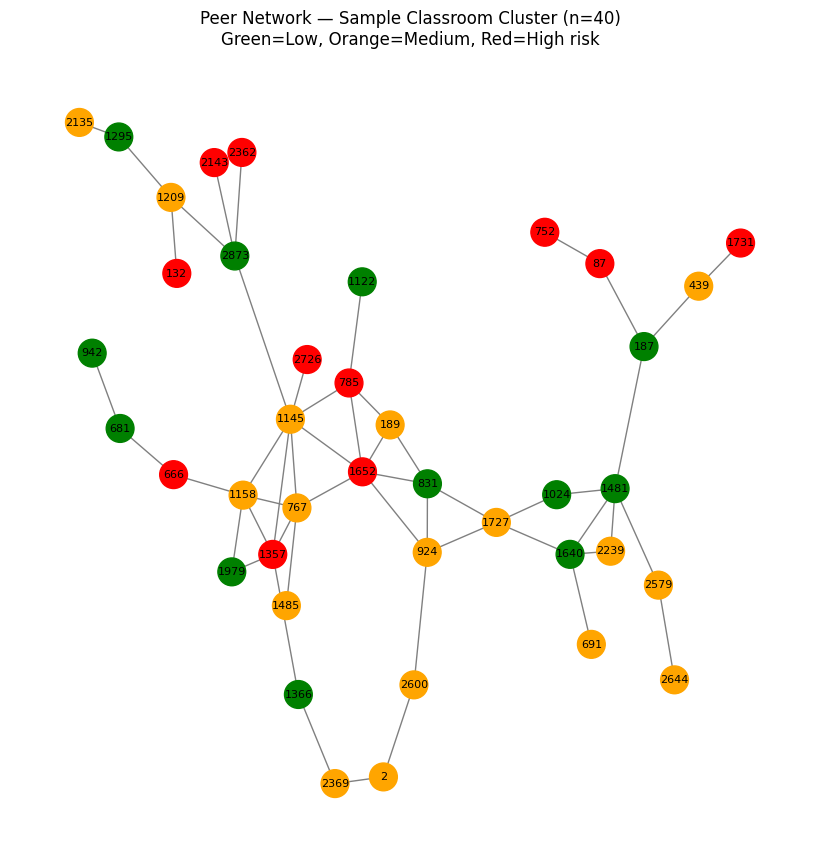

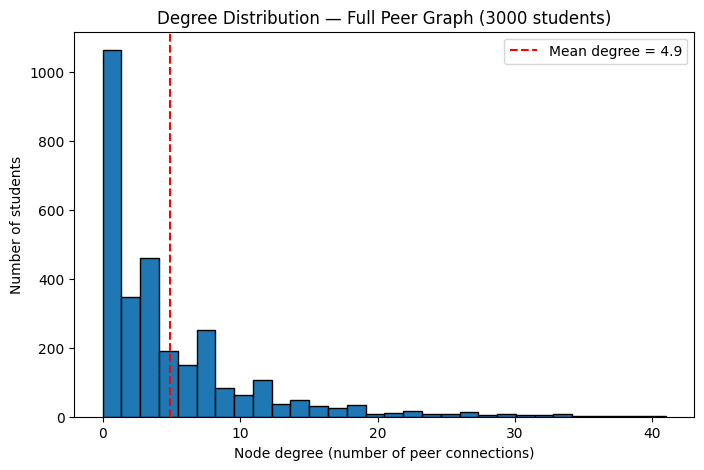

In [53]:
import networkx as nx
import matplotlib.pyplot as plt

edge_index_np = data.edge_index.numpy()
G_full = nx.Graph()
G_full.add_nodes_from(range(data.x.shape[0]))
edges_no_loops = [(int(s), int(t)) for s, t in zip(edge_index_np[0], edge_index_np[1]) if s != t]
G_full.add_edges_from(edges_no_loops)

components = sorted(nx.connected_components(G_full), key=len, reverse=True)
component_sizes = [len(c) for c in components]
print("Number of components:", len(components))
print("Largest 10 component sizes:", component_sizes[:10])

target_component = next((c for c in components if 15 <= len(c) <= 40), components[0])
print(f"\nSelected component size: {len(target_component)}")

# ============ PLOT 1: one classroom cluster in detail ============
subG = G_full.subgraph(target_component)
label_map_reverse = {0: 'Low', 1: 'Medium', 2: 'High'}
node_colors = [{'Low': 'green', 'Medium': 'orange', 'High': 'red'}[label_map_reverse[data.y[n].item()]]
               for n in subG.nodes()]

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(subG, seed=42)
nx.draw(subG, pos, node_color=node_colors, with_labels=True, node_size=400,
        font_size=8, edge_color='gray')
plt.title(f"Peer Network — Sample Classroom Cluster (n={len(target_component)})\nGreen=Low, Orange=Medium, Red=High risk")
plt.savefig('Synthetic_school_classroom_cluster_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ============ PLOT 2: full-graph degree distribution ============
degrees = [d for _, d in G_full.degree()]
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=30, edgecolor='black')
plt.xlabel('Node degree (number of peer connections)')
plt.ylabel('Number of students')
plt.title('Degree Distribution — Full Peer Graph (3000 students)')
plt.axvline(sum(degrees)/len(degrees), color='red', linestyle='--', label=f'Mean degree = {sum(degrees)/len(degrees):.1f}')
plt.legend()
plt.savefig('Synthetic_school_data_degree_distribution_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
from scipy.sparse import coo_matrix, save_npz
import numpy as np
import pickle

num_nodes = data.x.shape[0]
edge_index_np = data.edge_index.numpy()

# sparse adjacency matrix
adj_sparse = coo_matrix(
    (np.ones(edge_index_np.shape[1]), (edge_index_np[0], edge_index_np[1])),
    shape=(num_nodes, num_nodes)
)

print("Sparse adjacency matrix shape:", adj_sparse.shape)
print("Non-zero entries (directed edges incl. self-loops):", adj_sparse.nnz)

# adjacency list, excluding self-loops for readability
adj_list = {i: [] for i in range(num_nodes)}
for src, tgt in zip(edge_index_np[0], edge_index_np[1]):
    if src != tgt:
        adj_list[src].append(int(tgt))

sample_student = 0
print(f"\nStudent {sample_student} is connected to {len(adj_list[sample_student])} peers:")
print(adj_list[sample_student][:10], "..." if len(adj_list[sample_student]) > 10 else "")

# save with v2 naming, consistent with the rest of the corrected files
save_npz('synthetic_adjacency_matrix.npz', adj_sparse.tocsr())
with open('synthetic_adjacency_list_v.pkl', 'wb') as f:
    pickle.dump(adj_list, f)

print("\nSaved both files")

Sparse adjacency matrix shape: (3000, 3000)
Non-zero entries (directed edges incl. self-loops): 17696

Student 0 is connected to 1 peers:
[1965] 

Saved both files


In [52]:
from google.colab import files
files.download('synthetic_adjacency_matrix.npz')
files.download('synthetic_adjacency_list_v.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
files.download('Synthetic_school_classroom_cluster_v2.png')
files.download('Synthetic_school_data_degree_distribution_v2.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>